In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df = pd.read_csv(r'C:\Users\user\Desktop\data-science-journey\Loan_default.csv')

df

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


In [44]:
# first look throught the dataset

def first_look(df):
    print(f' --- data shape ---')
    print(df.shape)
    print(f' --- data types ---')
    print(df.dtypes)
    print(f'\n null values')
    print(df.isnull().sum())

first_look(df)

 --- data shape ---
(255347, 18)
 --- data types ---
LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object

 null values
LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


In [45]:
# 1. Shape

df.shape

(255347, 18)

In [46]:
# 2. What the data actually looks like

df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [47]:
# 3. Missing values

df.isnull().sum()
print(f' total missing values: {df.isnull().sum().sum()}')

 total missing values: 0


In [48]:
# 4. Data types

df.dtypes

LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object

In [49]:
# 5. Unique values in categorical columns

for col in df.select_dtypes('object').columns:
    print(f'{col}: {df[col].unique()}')


LoanID: ['I38PQUQS96' 'HPSK72WA7R' 'C1OZ6DPJ8Y' ... 'XQK1UUUNGP' 'JAO28CPL4H'
 'ZTH91CGL0B']
Education: ["Bachelor's" "Master's" 'High School' 'PhD']
EmploymentType: ['Full-time' 'Unemployed' 'Self-employed' 'Part-time']
MaritalStatus: ['Divorced' 'Married' 'Single']
HasMortgage: ['Yes' 'No']
HasDependents: ['Yes' 'No']
LoanPurpose: ['Other' 'Auto' 'Business' 'Home' 'Education']
HasCoSigner: ['Yes' 'No']


In [50]:
df['Default'].value_counts(normalize = True)* 100

Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64

In [51]:
# 6. Target variable distribution — what is the default rate?

print(df['Default'].value_counts())
print(f' dafault rate: {df['Default'].mean() * 100:.1f}%')

Default
0    225694
1     29653
Name: count, dtype: int64
 dafault rate: 11.6%


In [52]:
# 7. Statistical summary — spot impossible values here

df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


DATA CLEANING

In [53]:
# CHECK FOR DUPLIACATES

df[df.duplicated()]

# from this it is clear no duplicates is found

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default


In [54]:
df

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


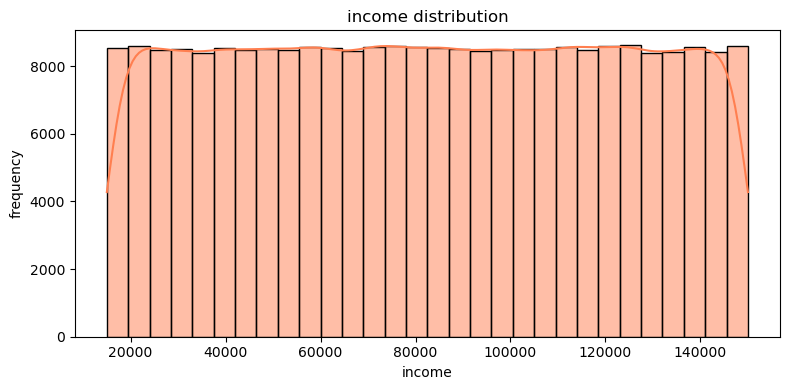

In [55]:
# income distribution, the income column is properly distributed that is symmetrical

plt.figure(figsize = (8, 4))
sns.histplot(df['Income'], kde = True, color = 'coral', bins = 30)
plt.title('income distribution')
plt.xlabel('income')
plt.ylabel('frequency')
plt.tight_layout()
plt.show()

# since income chart is symmetric, which means that the income is properly
# distributed, no skewness as that would have cuased bias in the proposed model.
# log transform will not be needed for this.

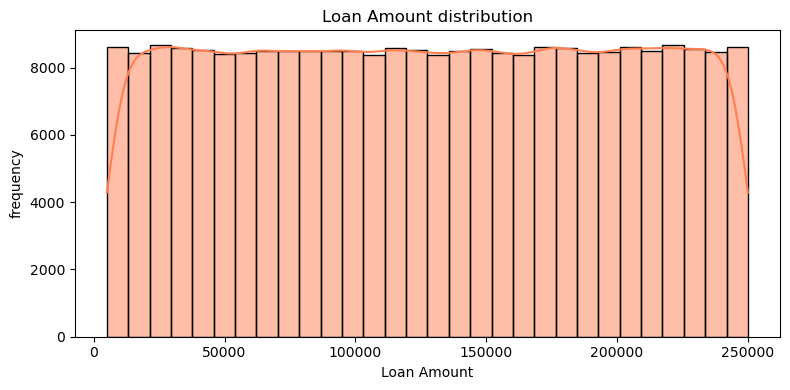

In [56]:
# loan amount distribution, the loan amount column is properly distributed that is symmetrical

plt.figure(figsize = (8, 4))
sns.histplot(df['LoanAmount'], kde = True, color = 'coral', bins = 30)
plt.title('Loan Amount distribution')
plt.xlabel('Loan Amount')
plt.ylabel('frequency')
plt.tight_layout()
plt.show()

# since Loan Mount chart is symmetric, which means that the Loan Amount is properly
# distributed, no skewness that would have cuased bias in the proposed model.
# log transform will not be needed for this.

In [57]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


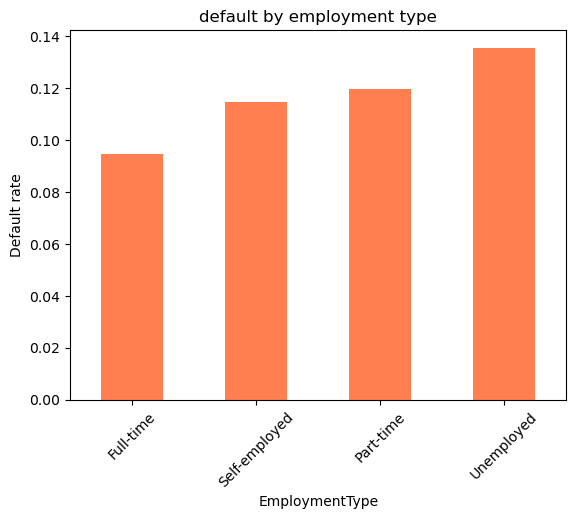

In [58]:
# defaulter by employment type

df.groupby('EmploymentType')['Default'].mean().sort_values().plot(kind = 'bar', color = 'coral')
plt.title('default by employment type')
plt.ylabel('Default rate')
plt.xticks(rotation = 45)
# plt.xlabel('employmeny type')
plt.show()

# from this, it is obvious that the people that default most is the unemployed with a default rate of ~0.135
# in as much as the unemployed people default more, the part time with 0.1196 and self employed with 0.1146 people are not far of, 
# and the difference is 0.0158 and 0.0209 respectively, they should also be looked into.

# and also full time employees has the lowest default rate of 0.095.
# which means that stable income equals low default risk
# so bank should weight employment stability heavely when making loan decisions.

In [59]:
df.groupby('EmploymentType')['Default'].mean().sort_values(ascending = False)

EmploymentType
Unemployed       0.135529
Part-time        0.119652
Self-employed    0.114620
Full-time        0.094634
Name: Default, dtype: float64

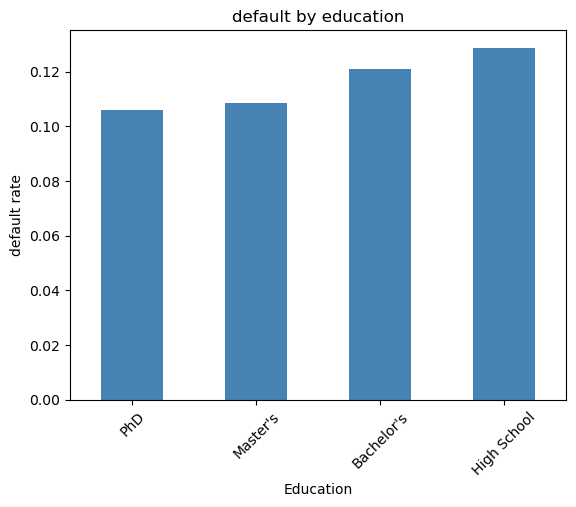

In [60]:
# default by education

df.groupby('Education')['Default'].mean().sort_values().plot(kind = 'bar', color = 'steelblue')
plt.title('default by education')
plt.ylabel('default rate')
plt.xticks(rotation = 45)
plt.show()

# from this chart, it is clear that the high school leavers has the highest dafault rate of 0.1287(12.87%) and the lowest is 0.105(10.5) that is a 2.3% difference
# this means that education alone is not strong prediction for defaulters, as all educational levels has roughly same default rate.


In [61]:
df.groupby('Education')['Default'].mean().sort_values(ascending = False)

Education
High School    0.128789
Bachelor's     0.121011
Master's       0.108717
PhD            0.105860
Name: Default, dtype: float64

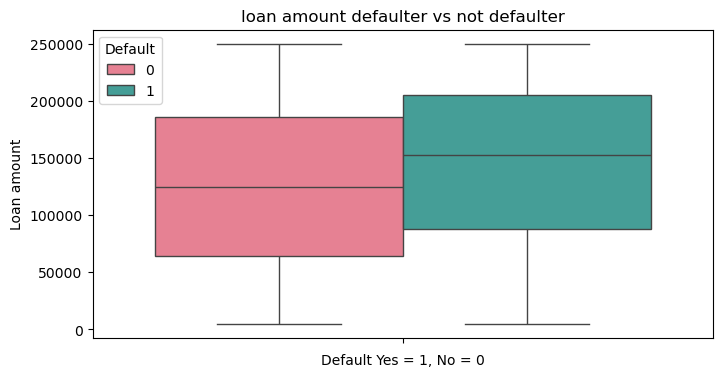

In [62]:
# boxplot for loan amount for defaulters and non defaulters


plt.figure(figsize = (8, 4))
sns.boxplot(data = df, hue = 'Default', y = 'LoanAmount', palette = 'husl')
plt.title('loan amount defaulter vs not defaulter')
plt.xlabel('Default Yes = 1, No = 0')
plt.ylabel('Loan amount')
plt.show()

# with iqr of the loan amount defaulter 150,000 higher than non defaulter 125,000, it shows that defaulter has higher max value
# that means that the highest money the defaulter has not paid is higher than the highest money the non defaulter has paid.

# from the chart, it is observed that defaulter take out larger loans(defaulter median = 150k and non defaulter median = 125k)
# this is useful as higher loan amount = higher defalt risk
# the bank should be cautious of large loan applications especially combined with other risk factors like unemployemnt

In [63]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [64]:
# Skewness of all numerical columns

numerical_col = df.select_dtypes('number').columns
print(df[numerical_col].skew().round(2))

# with default having skewness of 2.4, transformation is not needed as it is the target and not a feature.
# we never transform the target in classification. and the 2.4 skewness simply reflect class inbalance(88% , 12%) and can be handle.

Age               0.0
Income           -0.0
LoanAmount       -0.0
CreditScore       0.0
MonthsEmployed   -0.0
NumCreditLines   -0.0
InterestRate      0.0
LoanTerm         -0.0
DTIRatio         -0.0
Default           2.4
dtype: float64


In [65]:
# check for unique values for all category columns

for col in df.select_dtypes('object').columns:
    print(f'\n{col}:')
    print(df[col].value_counts())


LoanID:
LoanID
ZTH91CGL0B    1
I38PQUQS96    1
HPSK72WA7R    1
QU29Z1EVQI    1
QXBHNXNA9X    1
             ..
0HGZQKJ36W    1
H8GXPAOS71    1
A9S62RQ7US    1
EY08JDHTZP    1
V2KKSFM3UN    1
Name: count, Length: 255347, dtype: int64

Education:
Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64

EmploymentType:
EmploymentType
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64

MaritalStatus:
MaritalStatus
Married     85302
Divorced    85033
Single      85012
Name: count, dtype: int64

HasMortgage:
HasMortgage
Yes    127677
No     127670
Name: count, dtype: int64

HasDependents:
HasDependents
Yes    127742
No     127605
Name: count, dtype: int64

LoanPurpose:
LoanPurpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64

HasCoSigner:
HasCoSigner
Yes    127701
No     127646
Name: cou

DATA CLEANING AND PREPARATION

In [66]:
# drop the identifier columns that is the LoanID column
# it is an identifier not a feature, so it not important to this analysis.

df = df.drop(columns = ['LoanID'])

In [67]:
print(f'columns remaining: {df.shape}')

columns remaining: (255347, 17)


In [68]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [69]:
# Encoding the binary yes/no columns
# converting 'HasMortgage', 'HasDependents', 'HasCoSigner' to 1 and 0

binary_cols = ['HasMortgage', 'HasDependents', 'HasCoSigner']

for col in binary_cols:
    df[col] = (df[col] == 'Yes').astype(int)

print(df[binary_cols].head())

   HasMortgage  HasDependents  HasCoSigner
0            1              1            1
1            0              0            1
2            1              1            0
3            0              0            0
4            0              1            0


In [70]:
# Encoding the remaining category colmns
# education, employment type, marita status, and loan purpose.
# since they have no order or value order, i use one one-hot encoding

df = pd.get_dummies(
    df,
   columns = ['Education', 'EmploymentType', 'MaritalStatus', 'LoanPurpose'], drop_first = True
)

print(f' shape after encoding: {df.shape}')
print(df.columns.tolist())

# after the one-hot encoding, the columns remaining is 25, 
# and it make sense as this columns needed for the model

 shape after encoding: (255347, 25)
['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'HasMortgage', 'HasDependents', 'HasCoSigner', 'Default', 'Education_High School', "Education_Master's", 'Education_PhD', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other']


In [71]:
# separate feature and target

x = df.drop(columns = 'Default')
y = df['Default']
print(f' feature shape: {x.shape}')
print(f'target shape: {y.shape}')
print(f'default rate: {y.mean()*100:.2f}%')

 feature shape: (255347, 24)
target shape: (255347,)
default rate: 11.61%


In [72]:
# scale the numerical features

from sklearn.preprocessing import RobustScaler

num_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore',
            'MonthsEmployed', 'NumCreditLines', 'InterestRate',
            'LoanTerm', 'DTIRatio']

scaler = RobustScaler()

x[num_cols] = scaler.fit_transform(x[num_cols])

print(f'\n after scaling - the first 3 rows of numerical columns:')
print(x[num_cols].head(3).round(3))


 after scaling - the first 3 rows of numerical columns:
    Age  Income  LoanAmount  CreditScore  MonthsEmployed  NumCreditLines  \
0  0.52   0.052      -0.627       -0.196           0.333             2.0   
1  1.04  -0.475      -0.025       -0.422          -0.750            -1.0   
2  0.12   0.026       0.013       -0.447          -0.567             1.0   

   InterestRate  LoanTerm  DTIRatio  
0         0.154       0.0    -0.150  
1        -0.753       1.0     0.450  
2         0.672      -0.5    -0.475  


In [73]:
# correllation check
# which feature correllate most with features

numeric_df = df.select_dtypes(include = ['number'])

if 'Default' in numeric_df.columns:

    correllate_with_target = numeric_df.corr()['Default'].drop('Default')
    print(f'\ntop 10 feature correllated with default:')
    print(correllate_with_target.abs().sort_values(ascending = False).head(10))

# looking at the correllation with default, age with 0.1677 has the highest correllation score followed by interest rate with 0.1312
# and the lowest is has mortgage with 0.02285.
# age is surprising cause i was expecting income of loan amount to be higher.
# this means that younger people may have less financial stability, less credit history, lower savings, and more likely to default.


top 10 feature correllated with default:
Age               0.167783
InterestRate      0.131273
Income            0.099119
MonthsEmployed    0.097374
LoanAmount        0.086659
HasCoSigner       0.039109
HasDependents     0.034678
CreditScore       0.034166
NumCreditLines    0.028330
HasMortgage       0.022856
Name: Default, dtype: float64


In [74]:
default_age_group = df.groupby(pd.cut(df['Age'], bins = [17, 27, 39, 49, 59, 69]))['Default'].mean()

default_age_group
# from this table, from the observation age from 17 to 39 contribute to ~0.346 default rate and that is higher the rest age group combined.
# it is clear that the younger the people the higher the tendency of default.

Age
(17, 27]    0.202489
(27, 39]    0.146637
(39, 49]    0.101079
(49, 59]    0.073165
(59, 69]    0.051272
Name: Default, dtype: float64

MACHINE LEARNING MODEL

In [75]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                                confusion_matrix,
                                roc_auc_score,
                                ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

TRAIN/TEST SPLIT

In [76]:
#x = df.drop(columns = 'Default')
#y = df['Default']

x = x.copy()   # x is the scaled feature above
y = df['Default']

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y          #very important - maintains the 11.6% default rate in both sets
)

print(f'train size: {x_train.shape}')
print(f'test size: {x_test.shape}')
print(f'default rate in train: {y_train.mean()*100:.2f}')
print(f'default rate in test: {y_test.mean()*100:.2f}')


train size: (204277, 24)
test size: (51070, 24)
default rate in train: 11.61
default rate in test: 11.61


BUILD AND COMPARE 3 MODEL

In [80]:
# because the data is already scaled, we don't need scaler in pipeline
# for best practice, it was still added but pipeline is safer

models = {
    'Logistic Regression': LogisticRegression(
        random_state = 42,
        max_iter = 1000,
        class_weight = 'balanced'     # handle class imbalance
    ),

    'Decision Tree': DecisionTreeClassifier(
        max_depth = 5,
        random_state = 42,
        class_weight = 'balanced'
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators = 1000,
        random_state = 42, 
        class_weight = 'balanced',
        n_jobs = -1
    )
}

results = {}

for name, model in models.items():
    # build pipeline
    pipeline = Pipeline([
        ('scaler', RobustScaler()),
        ('model', model)
    ])

    # train
    pipeline.fit(x_train, y_train)

    # predict

    y_pred = pipeline.predict(x_test)
    y_prob = pipeline.predict_proba(x_test)[:, 1]

    # evaluate

    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'pipeline': pipeline, 'auc': auc,
                   'y_pred': y_pred, 'y_prob': y_prob}

    print(f'\n{'='*50}')
    print(f'MODEL: {model}')
    print(f'{'='*50}')

    print(classification_report(
        y_test, y_pred, target_names = ['No Default', 'Default']
    ))

    print(f'roc_auc score: {auc:.2f}')


MODEL: LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
              precision    recall  f1-score   support

  No Default       0.94      0.67      0.79     45139
     Default       0.22      0.70      0.33      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.68      0.73     51070

roc_auc score: 0.75

MODEL: DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
              precision    recall  f1-score   support

  No Default       0.94      0.67      0.78     45139
     Default       0.21      0.66      0.31      5931

    accuracy                           0.66     51070
   macro avg       0.57      0.66      0.55     51070
weighted avg       0.85      0.66      0.72     51070

roc_auc score: 0.72

MODEL: RandomForestClassifier(class_weight='balanced', n_estimators=1000, n_jobs=-1,
                       random_state=42)
          


best model: Logistic Regression


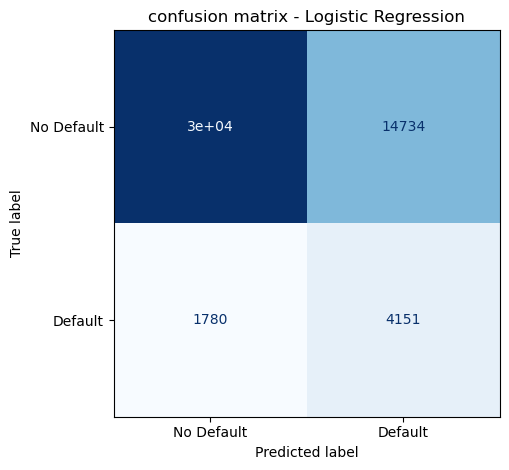

In [83]:
# find the best model by AUC

best_name = max(results, key = lambda x : results[x]['auc'])
print(f'\nbest model: {best_name}')

# plot confusion matrix

cm = confusion_matrix(y_test, results[best_name]['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix = cm, 
                             display_labels = ['No Default', 'Default'])
disp.plot(cmap = 'Blues', colorbar = False)
plt.title(f'confusion matrix - {best_name}')
plt.tight_layout()
plt.show()


# After plotting, answer these:
# How many defaulters did the model correctly catch? (True Positives)
# the number of defaulter is 4151 people defaulted

# How many defaulters did the model miss? (False Negatives)
# the defaulter missed is 1780 people

# For a bank, which of these errors is more costly?
# the defaulter missed is more costly as this will make the bank to give out loan to people that has high rate of defaulting thereby costing the bank.

CROSS VALIDATION

In [89]:
best_pipeline = results[best_name]['pipeline']

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
cv_score = cross_val_score(best_pipeline, x, y, cv = cv, scoring = 'roc_auc', n_jobs = -1)

print(f'\ncross validation result: {best_pipeline}')
print(f'AUC per fold: {cv_score.round(3)}')
print(f'mean AUC: {cv_score.mean():.3f}')
print(f'std AUC: {cv_score.std():.2f}')


cross validation result: Pipeline(steps=[('scaler', RobustScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])
AUC per fold: [0.745 0.747 0.747 0.752 0.749]
mean AUC: 0.748
std AUC: 0.00


FEATURE IMPORTANCE

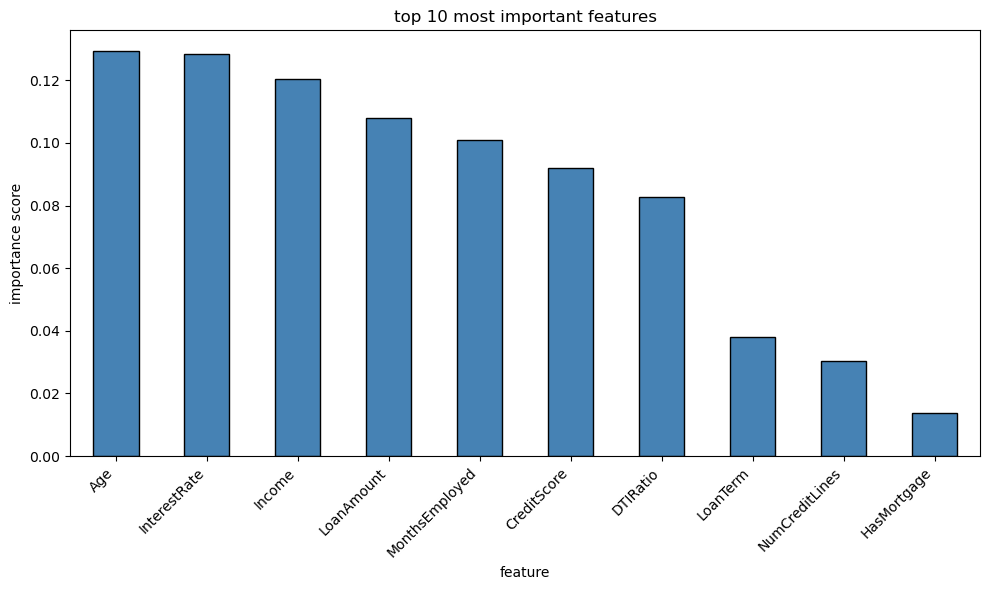


top ten features:
Age               0.1295
InterestRate      0.1284
Income            0.1202
LoanAmount        0.1081
MonthsEmployed    0.1010
CreditScore       0.0918
DTIRatio          0.0827
LoanTerm          0.0379
NumCreditLines    0.0303
HasMortgage       0.0137
dtype: float64


In [95]:
# Extract from Random Forest specifically

rf_pipeline = results['Random Forest']['pipeline']
rf_model = rf_pipeline.named_steps['model']

feat_importance = pd.Series(
    rf_model.feature_importances_,
    index = x_train.columns).sort_values(ascending = False)

plt.figure(figsize = (10, 6))
feat_importance.head(10).plot(kind = 'bar',
                              color = 'steelblue',
                              edgecolor = 'black')
plt.title('top 10 most important features')
plt.ylabel('importance score')
plt.xlabel('feature')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

print(f'\ntop ten features:')
print(feat_importance.head(10).round(4))

In [1]:
# What is the scale of the dataset and the problem?
#  (how many loan applicants, what is the default rate)

# the total dataset is 255347 rows, that is the total number of applicant is 255347
# non defaulters is 225,694 and the 88.38% while defaulters is 29,653 that is, the dafualt rate is 11.61%

# What did EDA reveal about who defaults?
#  (age groups, employment type, loan amount findings)

# from analysis, it is clear that stable job has a low rate of defaulting with a defaut rate of 0.095 compared to 
# umemployed and part time with a default rate of 0.135529 and 0.119652 respectively.
# so bank should consider stable income people  more for loan as they have low defaault rate.
